# Mentor implementations compared with our withdrawal model

This notebook answers two simple questions:

1. Do the three repositories predict the same outcome as us?
2. If one does, does it still perform better when we give both models the same information and evaluation split?

**Our fixed problem**

- Positive class: `final_result == "Withdrawn"`
- Negative class: `Pass`, `Fail`, or `Distinction`
- Primary observation point: 25% of each module presentation
- Primary evaluation: student-grouped 70/15/15 partition from `checkpoint1_EDA_v3.ipynb`
- Frozen best result: PR-AUC **0.825**, ROC-AUC **0.884**

Khorasani is the only exact target match. We run it in four ways so that unlike-for-like results are not mixed together:

1. with outcome-revealing fields, only to explain the near-perfect headline;
2. as released, using clean day-28 features and a row split;
3. at day 28 after fixing student/enrolment grouping;
4. at our 25% checkpoint using our student-grouped evaluation.

A high score is treated as comparable only when the target, information window, entity keys, and evaluation partition all match.

## Which repositories really match our problem?

| Repository | Actual problem and reported outcome | Verdict |
|---|---|---|
| [Khorasani: OULAD fairness](https://github.com/valakhorasani/oulad-fairness) | Exact target: `Withdrawn = 1`, everything else `= 0`. The accompanying paper source reports ROC-AUC 0.995 with outcome-derived variables and 0.805 after removing them. The clean notebook uses VLE evidence through day 28. | **Exact target reimplemented.** The 0.995 result is a leakage diagnostic, not a deployable model. |
| [UnfairSlayers Seldonian OULAD](https://github.com/pranay-ar/UnfairSlayers_Seldonian_oulad) | Its [preprocessing code](https://github.com/pranay-ar/UnfairSlayers_Seldonian_oulad/blob/main/preprocess.py) maps `Pass + Distinction = 1` and `Fail + Withdrawn = 0`. Its experiments optimize log loss under fairness constraints rather than report withdrawal ROC/PR-AUC. | **Different target and metric; documented but not reimplemented.** |
| [KANUBALAD school dropout fairness](https://github.com/KANUBALAD/ML-Fairness-in-School-DropOut-) | The current [data loader](https://github.com/KANUBALAD/ML-Fairness-in-School-DropOut-/blob/main/src/dataload.py) supports Brazilian, African, and Indian dropout datasets. The current branch contains no OULAD `studentInfo`, `final_result`, or `Withdrawn` pipeline. | **Different datasets; not reimplemented.** |

### Why Khorasani's original result is not immediately comparable

- VLE activity is grouped only by student, so activity from different course enrolments can be mixed.
- Rows are split randomly, allowing the same student to appear in both training and test data.
- It observes students through day 28; our 25% checkpoint occurs around days 58–67.
- Its notebook has no saved outputs, so we rerun the method instead of accepting the stated numbers.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
KEYS = ["id_student", "code_module", "code_presentation"]
SENSITIVE = ["disability", "imd_band", "age_band", "highest_education"]
BASELINE = {
    "variant": "Current checkpoint1_EDA_v3 HGB",
    "model": "HistGradientBoosting, withdrawal weight 3.0",
    "window": "25% course-relative",
    "split": "student-grouped evaluation",
    "pr_auc": 0.8248301223758441,
    "roc_auc": 0.8841793059527716,
    "balanced_accuracy": 0.8191925703658556,
    "precision": 0.6929971988795518,
    "recall": 0.8032467532467532,
    "f1": 0.7440601503759399,
    "fp": 548,
    "fn": 303,
}

def locate_oulad(start):
    start = Path(start).resolve()
    for parent in [start, *start.parents]:
        candidate = parent / "open+university+learning+analytics+dataset"
        if (candidate / "studentInfo.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the OULAD CSV directory")

DATA_DIR = locate_oulad(Path.cwd())
print("MLDL-ready OULAD directory:", DATA_DIR)
display(pd.DataFrame([BASELINE]))

MLDL-ready OULAD directory: C:\Users\creak\Downloads\eMasters Capstone Project\open+university+learning+analytics+dataset


,variant,model,window,split,pr_auc,roc_auc,balanced_accuracy,precision,recall,f1,fp,fn
0,Current checkpoint1_EDA_v3 HGB,"HistGradientBoosting, withdrawal weight 3.0",25% course-relative,student-grouped evaluation,0.82483,0.884179,0.819193,0.692997,0.803247,0.74406,548,303


In [2]:
courses = pd.read_csv(DATA_DIR / "courses.csv")
assessments = pd.read_csv(DATA_DIR / "assessments.csv")
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_registration = pd.read_csv(DATA_DIR / "studentRegistration.csv")
student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
student_vle = pd.read_csv(
    DATA_DIR / "studentVle.csv",
    dtype={
        "code_module": "category",
        "code_presentation": "category",
        "id_student": "int32",
        "id_site": "int32",
        "date": "int16",
        "sum_click": "int32",
    },
)

student_info["target_withdrawn"] = (student_info["final_result"] == "Withdrawn").astype("int8")
assert student_info.loc[student_info.final_result == "Withdrawn", "target_withdrawn"].eq(1).all()
assert student_info.loc[student_info.final_result != "Withdrawn", "target_withdrawn"].eq(0).all()
assert student_info.duplicated(KEYS).sum() == 0

target_audit = pd.crosstab(student_info["final_result"], student_info["target_withdrawn"])
display(target_audit)
print("Rows:", len(student_info), "Unique students:", student_info.id_student.nunique())

target_withdrawn,0,1
final_result,,
Distinction,3024,0
Fail,7052,0
Pass,12361,0
Withdrawn,0,10156


Rows: 32593 Unique students: 28785


## Simple split and timing check

We first reproduce their split, then measure how many students appear on both sides. We also show how day 28 compares with our 25% checkpoint.

In [3]:
y_all = student_info["target_withdrawn"]
row_train_idx, row_test_idx = train_test_split(
    np.arange(len(student_info)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

row_train_students = set(student_info.iloc[row_train_idx].id_student)
row_test_students = set(student_info.iloc[row_test_idx].id_student)
overlap_students = row_train_students & row_test_students

enrolments_per_student = student_info.groupby("id_student").size()
courses["checkpoint_day_25pct"] = (courses["module_presentation_length"] * 0.25).round().astype(int)

overlap_audit = pd.DataFrame([{
    "rows": len(student_info),
    "unique_students": student_info.id_student.nunique(),
    "students_with_multiple_enrolments": int((enrolments_per_student > 1).sum()),
    "train_test_student_overlap": len(overlap_students),
    "test_students_seen_in_train_pct": 100 * len(overlap_students) / len(row_test_students),
    "minimum_25pct_day": courses.checkpoint_day_25pct.min(),
    "maximum_25pct_day": courses.checkpoint_day_25pct.max(),
}])
display(overlap_audit.style.format({"test_students_seen_in_train_pct": "{:.1f}%"}))
assert len(overlap_students) > 0, "The source row split was expected to contain repeated students."

,rows,unique_students,students_with_multiple_enrolments,train_test_student_overlap,test_students_seen_in_train_pct,minimum_25pct_day,maximum_25pct_day
0,32593,28785,3538,1121,17.6%,58,67


In [4]:
def aggregate_vle(events, group_keys):
    events = events.copy()
    basic = (
        events.groupby(group_keys, observed=True)
        .agg(
            total_clicks=("sum_click", "sum"),
            active_days=("date", "nunique"),
            max_clicks_single_day=("sum_click", "max"),
        )
        .reset_index()
    )
    basic["mean_clicks_per_active_day"] = (
        basic["total_clicks"] / basic["active_days"].clip(lower=1)
    )

    weekly_events = events.copy()
    weekly_events["week"] = (weekly_events["date"] // 7).astype(int)
    weekly = (
        weekly_events.groupby(group_keys + ["week"], observed=True)["sum_click"]
        .sum()
        .reset_index()
    )
    weekly_agg = (
        weekly.groupby(group_keys, observed=True)["sum_click"]
        .agg(weekly_clicks_mean="mean", weekly_clicks_std="std")
        .fillna(0)
        .reset_index()
    )
    return basic.merge(weekly_agg, on=group_keys, how="left", validate="one_to_one")


VLE_FEATURES = [
    "total_clicks",
    "active_days",
    "max_clicks_single_day",
    "mean_clicks_per_active_day",
    "weekly_clicks_mean",
    "weekly_clicks_std",
]


def add_sensitive_flags(frame):
    result = frame.copy()
    result["imd_band"] = result["imd_band"].fillna("Missing")
    deprived = {"0-10%", "10-20%", "20-30%"}
    result["imd_deprived"] = result["imd_band"].isin(deprived).astype("int8")
    result["disabled_and_deprived"] = (
        (result["disability"] == "Y") & (result["imd_deprived"] == 1)
    ).astype("int8")
    return result


def source_faithful_features(include_outcome_leakage=False):
    # Mirrors the repository: registration and VLE aggregates are keyed only by student.
    registration_numeric = student_registration.copy()
    registration_numeric["date_registration"] = pd.to_numeric(
        registration_numeric["date_registration"], errors="coerce"
    )
    reg_agg = (
        registration_numeric.groupby("id_student", observed=True)
        .agg(
            n_registrations=("code_module", "count"),
            mean_reg_date=("date_registration", "mean"),
        )
        .reset_index()
    )
    vle_day28 = student_vle[student_vle["date"] <= 28].copy()
    vle_agg = aggregate_vle(vle_day28, ["id_student"])
    due = (
        assessments.groupby(["code_module", "code_presentation"], observed=True)["date"]
        .min()
        .rename("days_to_first_due")
        .reset_index()
    )

    base_cols = KEYS + ["final_result", "target_withdrawn"] + SENSITIVE
    result = student_info[base_cols].copy()
    result = result.merge(reg_agg, on="id_student", how="left", validate="many_to_one")
    result = result.merge(vle_agg, on="id_student", how="left", validate="many_to_one")
    result = result.merge(
        due, on=["code_module", "code_presentation"], how="left", validate="many_to_one"
    )
    result[VLE_FEATURES] = result[VLE_FEATURES].fillna(0)

    numeric = ["n_registrations", "mean_reg_date", "days_to_first_due"] + VLE_FEATURES
    features = ["code_module", "code_presentation"] + numeric

    if include_outcome_leakage:
        # The paper describes these variables but the released clean notebook does not
        # contain executable construction code. This transparent reconstruction uses
        # the current enrolment key and is intentionally outcome-derived.
        reg_leak = student_registration[KEYS + ["date_unregistration"]].copy()
        reg_leak["has_unregistration"] = reg_leak["date_unregistration"].notna().astype("int8")
        reg_leak["date_unregistration_missing"] = reg_leak["date_unregistration"].isna().astype("int8")
        result = result.merge(reg_leak, on=KEYS, how="left", validate="one_to_one")

        assess_events = student_assessment.merge(
            assessments[["id_assessment", "code_module", "code_presentation", "date"]],
            on="id_assessment",
            how="left",
            validate="many_to_one",
        )
        assess_events["score"] = pd.to_numeric(assess_events["score"], errors="coerce")
        assess_events["date_submitted"] = pd.to_numeric(
            assess_events["date_submitted"], errors="coerce"
        )
        first_assessment = (
            assess_events.sort_values(KEYS + ["date", "id_assessment"])
            .groupby(KEYS, observed=True)
            .first()[["score", "date_submitted"]]
            .rename(columns={"score": "first_score"})
            .reset_index()
        )
        first_assessment["submitted_assessment"] = first_assessment["date_submitted"].notna().astype("int8")
        first_assessment["score_missing"] = first_assessment["first_score"].isna().astype("int8")
        result = result.merge(first_assessment, on=KEYS, how="left", validate="one_to_one")
        result["submitted_assessment"] = result["submitted_assessment"].fillna(0)
        result["score_missing"] = result["score_missing"].fillna(1)
        result["first_score"] = result["first_score"].fillna(0)
        result["date_submitted"] = result["date_submitted"].fillna(999)
        leak_features = [
            "has_unregistration",
            "date_unregistration_missing",
            "date_unregistration",
            "first_score",
            "date_submitted",
            "submitted_assessment",
            "score_missing",
        ]
        features += leak_features
    else:
        forbidden = {
            "has_unregistration", "date_unregistration", "date_submitted",
            "first_score", "submitted_assessment", "score_missing",
        }
        assert forbidden.isdisjoint(features)

    result = add_sensitive_flags(result)
    assert len(result) == len(student_info)
    assert result.duplicated(KEYS).sum() == 0
    return result, features


def corrected_features(window_day=None, checkpoint_fraction=None):
    if (window_day is None) == (checkpoint_fraction is None):
        raise ValueError("Provide exactly one of window_day or checkpoint_fraction")

    events = student_vle.copy()
    if window_day is not None:
        events = events[events["date"] <= window_day].copy()
        window_label = f"day_{window_day}"
        max_days_past_cutoff = int((events["date"] - window_day).max())
    else:
        cutoff = courses[["code_module", "code_presentation", "module_presentation_length"]].copy()
        cutoff["checkpoint_day"] = (
            cutoff["module_presentation_length"] * checkpoint_fraction
        ).round().astype(int)
        events = events.merge(
            cutoff[["code_module", "code_presentation", "checkpoint_day"]],
            on=["code_module", "code_presentation"],
            how="left",
            validate="many_to_one",
        )
        events = events[events["date"] <= events["checkpoint_day"]].copy()
        window_label = f"{checkpoint_fraction:.0%}_course_relative"
        max_days_past_cutoff = int((events["date"] - events["checkpoint_day"]).max())

    vle_agg = aggregate_vle(events, KEYS)
    due = (
        assessments.groupby(["code_module", "code_presentation"], observed=True)["date"]
        .min()
        .rename("days_to_first_due")
        .reset_index()
    )
    registration = student_registration[KEYS + ["date_registration"]].copy()
    registration["date_registration"] = pd.to_numeric(
        registration["date_registration"], errors="coerce"
    )

    base_cols = KEYS + ["final_result", "target_withdrawn"] + SENSITIVE
    result = student_info[base_cols].copy()
    result = result.merge(registration, on=KEYS, how="left", validate="one_to_one")
    result = result.merge(vle_agg, on=KEYS, how="left", validate="one_to_one")
    result = result.merge(
        due, on=["code_module", "code_presentation"], how="left", validate="many_to_one"
    )
    result[VLE_FEATURES] = result[VLE_FEATURES].fillna(0)
    result = add_sensitive_flags(result)

    features = ["code_module", "code_presentation", "date_registration", "days_to_first_due"] + VLE_FEATURES
    forbidden = {
        "has_unregistration", "date_unregistration", "date_submitted",
        "first_score", "submitted_assessment", "score_missing", "final_result",
    }
    assert forbidden.isdisjoint(features)
    assert len(result) == len(student_info)
    assert result.duplicated(KEYS).sum() == 0
    assert max_days_past_cutoff <= 0
    audit = {
        "window": window_label,
        "vle_records_used": len(events),
        "raw_predictors": len(features),
        "max_days_past_cutoff": max_days_past_cutoff,
    }
    return result, features, audit

In [5]:
started = time.time()
source_leaky, source_leaky_features = source_faithful_features(include_outcome_leakage=True)
source_clean, source_clean_features = source_faithful_features(include_outcome_leakage=False)
corrected_day28, corrected_day28_features, day28_audit = corrected_features(window_day=28)
corrected_25pct, corrected_25pct_features, pct25_audit = corrected_features(checkpoint_fraction=0.25)

feature_audit = pd.DataFrame([
    {
        "variant": "Paper-described leaky reconstruction",
        "target": "Withdrawn vs Others",
        "window": "day 28 plus outcome-derived evidence",
        "aggregation_key": "student only for VLE; enrolment for direct leakage",
        "raw_predictors": len(source_leaky_features),
        "comparable": False,
    },
    {
        "variant": "Repository-faithful clean",
        "target": "Withdrawn vs Others",
        "window": "day 28",
        "aggregation_key": "student only",
        "raw_predictors": len(source_clean_features),
        "comparable": False,
    },
    {
        "variant": "Corrected day 28",
        "target": "Withdrawn vs Others",
        "window": "day 28",
        "aggregation_key": "student-module-presentation",
        "raw_predictors": len(corrected_day28_features),
        "comparable": False,
    },
    {
        "variant": "Corrected 25% checkpoint",
        "target": "Withdrawn vs Others",
        "window": "days 58-67 by presentation",
        "aggregation_key": "student-module-presentation",
        "raw_predictors": len(corrected_25pct_features),
        "comparable": True,
    },
])
print(f"Feature construction completed in {time.time() - started:.1f}s")
display(feature_audit)
display(pd.DataFrame([day28_audit, pct25_audit]))

Feature construction completed in 9.1s


,variant,target,window,aggregation_key,raw_predictors,comparable
0,Paper-described leaky reconstruction,Withdrawn vs Others,day 28 plus outcome-derived evidence,student only for VLE; enrolment for direct lea...,18,False
1,Repository-faithful clean,Withdrawn vs Others,day 28,student only,11,False
2,Corrected day 28,Withdrawn vs Others,day 28,student-module-presentation,10,False
3,Corrected 25% checkpoint,Withdrawn vs Others,days 58-67 by presentation,student-module-presentation,10,True


,window,vle_records_used,raw_predictors,max_days_past_cutoff
0,day_28,2847851,10,0
1,25%_course_relative,4667957,10,0


In [6]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_pipeline(model_name, X, feature_columns):
    categorical = [c for c in feature_columns if not pd.api.types.is_numeric_dtype(X[c])]
    numeric = [c for c in feature_columns if c not in categorical]
    preprocess = ColumnTransformer([
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric,
        ),
        ("categorical", make_ohe(), categorical),
    ])

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
        ),
        "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE
        ),
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            verbosity=0,
            n_jobs=-1,
        ),
    }
    return Pipeline([("preprocess", preprocess), ("model", models[model_name])])


def metric_row(variant, model_name, y_true, probability, window, split, comparable):
    prediction = (np.asarray(probability) >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "variant": variant,
        "model": model_name,
        "window": window,
        "split": split,
        "comparable_to_baseline": comparable,
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


MODEL_NAMES = [
    "Logistic Regression", "Decision Tree", "Random Forest",
    "Gradient Boosting", "XGBoost",
]


def run_suite(variant, frame, feature_columns, train_idx, eval_idx, window, split, comparable):
    X_train = frame.iloc[train_idx][feature_columns]
    y_train = frame.iloc[train_idx]["target_withdrawn"]
    X_eval = frame.iloc[eval_idx][feature_columns]
    y_eval = frame.iloc[eval_idx]["target_withdrawn"]
    rows, probabilities, fitted = [], {}, {}
    for model_name in MODEL_NAMES:
        model = make_pipeline(model_name, X_train, feature_columns)
        model.fit(X_train, y_train)
        probability = model.predict_proba(X_eval)[:, 1]
        rows.append(metric_row(
            variant, model_name, y_eval, probability, window, split, comparable
        ))
        probabilities[model_name] = probability
        fitted[model_name] = model
    return pd.DataFrame(rows), probabilities, fitted


def formatted(frame):
    metric_columns = [
        "accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
    ]
    return frame.style.format({c: "{:.3f}" for c in metric_columns if c in frame.columns})

## Results using the repository's original setup

Both runs below use the repository's random 80/20 row split. The first deliberately includes information that reveals withdrawal; it is shown only to explain the very high score. The second removes those fields and represents the usable version.

In [7]:
leaky_results, leaky_probabilities, leaky_models = run_suite(
    "Paper-described leaky reconstruction",
    source_leaky,
    source_leaky_features,
    row_train_idx,
    row_test_idx,
    "day 28 plus outcome-derived evidence",
    "stratified row 80/20",
    False,
)
source_clean_results, source_clean_probabilities, source_clean_models = run_suite(
    "Repository-faithful clean",
    source_clean,
    source_clean_features,
    row_train_idx,
    row_test_idx,
    "day 28",
    "stratified row 80/20",
    False,
)

print("Leaky reconstruction (diagnostic only):")
display(formatted(leaky_results.sort_values("roc_auc", ascending=False)))
print("Repository-faithful clean implementation:")
display(formatted(source_clean_results.sort_values("pr_auc", ascending=False)))

Leaky reconstruction (diagnostic only):


,variant,model,window,split,comparable_to_baseline,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
3,Paper-described leaky reconstruction,Gradient Boosting,day 28 plus outcome-derived evidence,stratified row 80/20,False,0.998,0.997,1.000,0.994,0.997,1.000,1.000,4487,1,12,2019
0,Paper-described leaky reconstruction,Logistic Regression,day 28 plus outcome-derived evidence,stratified row 80/20,False,0.998,0.997,1.000,0.994,0.997,1.000,0.999,4487,1,12,2019
4,Paper-described leaky reconstruction,XGBoost,day 28 plus outcome-derived evidence,stratified row 80/20,False,0.998,0.997,0.999,0.994,0.996,1.000,1.000,4485,3,12,2019
1,Paper-described leaky reconstruction,Decision Tree,day 28 plus outcome-derived evidence,stratified row 80/20,False,0.998,0.996,0.999,0.994,0.996,0.999,0.998,4485,3,13,2018
2,Paper-described leaky reconstruction,Random Forest,day 28 plus outcome-derived evidence,stratified row 80/20,False,0.961,0.949,0.954,0.919,0.936,0.996,0.990,4397,91,165,1866


Repository-faithful clean implementation:


,variant,model,window,split,comparable_to_baseline,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
4,Repository-faithful clean,XGBoost,day 28,stratified row 80/20,False,0.788,0.701,0.756,0.470,0.580,0.806,0.702,4179,309,1076,955
3,Repository-faithful clean,Gradient Boosting,day 28,stratified row 80/20,False,0.785,0.697,0.754,0.461,0.572,0.804,0.698,4182,306,1094,937
2,Repository-faithful clean,Random Forest,day 28,stratified row 80/20,False,0.780,0.680,0.777,0.415,0.541,0.801,0.693,4246,242,1189,842
0,Repository-faithful clean,Logistic Regression,day 28,stratified row 80/20,False,0.776,0.691,0.715,0.467,0.565,0.784,0.657,4109,379,1082,949
1,Repository-faithful clean,Decision Tree,day 28,stratified row 80/20,False,0.776,0.697,0.702,0.486,0.575,0.781,0.652,4069,419,1043,988


## Results after making the evaluation safer

Here, every student belongs to only one partition. We use the same training and evaluation groups as our baseline, while keeping the final test partition untouched.

In [8]:
splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=RANDOM_STATE)
fold_id = np.full(len(student_info), -1, dtype=int)
for fold, (_, valid_idx) in enumerate(
    splitter.split(student_info, student_info["target_withdrawn"], groups=student_info["id_student"])
):
    fold_id[valid_idx] = fold

test_idx = np.where(np.isin(fold_id, [0, 1, 2]))[0]
eval_idx = np.where(np.isin(fold_id, [3, 4, 5]))[0]
train_idx = np.where(~np.isin(fold_id, [0, 1, 2, 3, 4, 5]))[0]

group_sets = {
    "train": set(student_info.iloc[train_idx].id_student),
    "evaluation": set(student_info.iloc[eval_idx].id_student),
    "test": set(student_info.iloc[test_idx].id_student),
}
assert group_sets["train"].isdisjoint(group_sets["evaluation"])
assert group_sets["train"].isdisjoint(group_sets["test"])
assert group_sets["evaluation"].isdisjoint(group_sets["test"])

split_audit = pd.DataFrame([
    {
        "partition": name,
        "rows": len(indices),
        "unique_students": student_info.iloc[indices].id_student.nunique(),
        "withdrawn": int(student_info.iloc[indices].target_withdrawn.sum()),
        "withdrawal_prevalence": student_info.iloc[indices].target_withdrawn.mean(),
    }
    for name, indices in [("train", train_idx), ("evaluation", eval_idx), ("test_reserved", test_idx)]
])
display(split_audit.style.format({"withdrawal_prevalence": "{:.3f}"}))

,partition,rows,unique_students,withdrawn,withdrawal_prevalence
0,train,22833,20138,7141,0.313
1,evaluation,4864,4317,1540,0.317
2,test_reserved,4896,4330,1475,0.301


In [9]:
day28_results, day28_probabilities, day28_models = run_suite(
    "Corrected day 28",
    corrected_day28,
    corrected_day28_features,
    train_idx,
    eval_idx,
    "day 28",
    "student-grouped evaluation",
    False,
)
pct25_results, pct25_probabilities, pct25_models = run_suite(
    "Corrected 25% checkpoint",
    corrected_25pct,
    corrected_25pct_features,
    train_idx,
    eval_idx,
    "25% course-relative",
    "student-grouped evaluation",
    True,
)

print("Corrected day-28 sensitivity run:")
display(formatted(day28_results.sort_values("pr_auc", ascending=False)))
print("Primary corrected 25%-checkpoint comparison:")
display(formatted(pd.concat([
    pd.DataFrame([BASELINE]),
    pct25_results.sort_values("pr_auc", ascending=False),
], ignore_index=True, sort=False)))

Corrected day-28 sensitivity run:


,variant,model,window,split,comparable_to_baseline,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
4,Corrected day 28,XGBoost,day 28,student-grouped evaluation,False,0.785,0.693,0.785,0.442,0.565,0.785,0.702,3138,186,860,680
3,Corrected day 28,Gradient Boosting,day 28,student-grouped evaluation,False,0.782,0.689,0.781,0.434,0.558,0.786,0.700,3136,188,871,669
2,Corrected day 28,Random Forest,day 28,student-grouped evaluation,False,0.780,0.682,0.794,0.414,0.544,0.785,0.695,3159,165,903,637
0,Corrected day 28,Logistic Regression,day 28,student-grouped evaluation,False,0.776,0.698,0.718,0.483,0.578,0.774,0.673,3032,292,796,744
1,Corrected day 28,Decision Tree,day 28,student-grouped evaluation,False,0.780,0.686,0.780,0.427,0.552,0.770,0.657,3138,186,882,658


Primary corrected 25%-checkpoint comparison:


,variant,model,window,split,pr_auc,roc_auc,balanced_accuracy,precision,recall,f1,fp,fn,comparable_to_baseline,accuracy,tn,tp
0,Current checkpoint1_EDA_v3 HGB,"HistGradientBoosting, withdrawal weight 3.0",25% course-relative,student-grouped evaluation,0.825,0.884,0.819,0.693,0.803,0.744,548,303,nan,nan,nan,nan
1,Corrected 25% checkpoint,XGBoost,25% course-relative,student-grouped evaluation,0.748,0.830,0.736,0.781,0.544,0.641,235,703,True,0.807,3089.000000,837.000000
2,Corrected 25% checkpoint,Gradient Boosting,25% course-relative,student-grouped evaluation,0.743,0.826,0.732,0.777,0.534,0.633,236,717,True,0.804,3088.000000,823.000000
3,Corrected 25% checkpoint,Random Forest,25% course-relative,student-grouped evaluation,0.739,0.823,0.720,0.801,0.497,0.613,190,775,True,0.802,3134.000000,765.000000
4,Corrected 25% checkpoint,Logistic Regression,25% course-relative,student-grouped evaluation,0.726,0.819,0.739,0.745,0.569,0.645,300,664,True,0.802,3024.000000,876.000000
5,Corrected 25% checkpoint,Decision Tree,25% course-relative,student-grouped evaluation,0.698,0.811,0.727,0.748,0.539,0.626,280,710,True,0.796,3044.000000,830.000000


,variant,model,window,split,comparable_to_baseline,pr_auc,roc_auc,balanced_accuracy,precision,recall,f1,fp,fn
0,Current checkpoint1_EDA_v3 HGB,"HistGradientBoosting, withdrawal weight 3.0",25% course-relative,student-grouped evaluation,nan,0.825,0.884,0.819,0.693,0.803,0.744,548,303
1,Corrected 25% checkpoint,XGBoost,25% course-relative,student-grouped evaluation,True,0.748,0.830,0.736,0.781,0.544,0.641,235,703
2,Corrected day 28,XGBoost,day 28,student-grouped evaluation,False,0.702,0.785,0.693,0.785,0.442,0.565,186,860
3,Paper-described leaky reconstruction,Gradient Boosting,day 28 plus outcome-derived evidence,stratified row 80/20,False,1.000,1.000,0.997,1.000,0.994,0.997,1,12
4,Repository-faithful clean,XGBoost,day 28,stratified row 80/20,False,0.702,0.806,0.701,0.756,0.470,0.580,309,1076


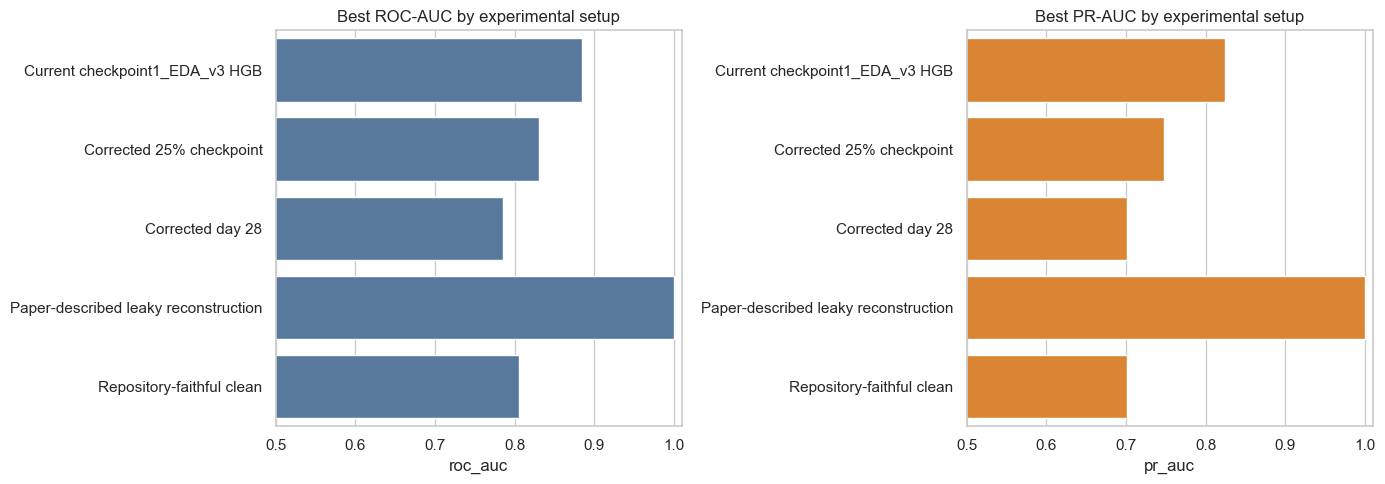

In [10]:
all_results = pd.concat(
    [leaky_results, source_clean_results, day28_results, pct25_results],
    ignore_index=True,
)
best_by_variant = (
    all_results.sort_values(["variant", "pr_auc", "roc_auc"], ascending=[True, False, False])
    .groupby("variant", as_index=False)
    .first()
)

comparison_summary = pd.concat([
    pd.DataFrame([BASELINE]),
    best_by_variant,
], ignore_index=True, sort=False)
display(formatted(comparison_summary[[
    "variant", "model", "window", "split", "comparable_to_baseline",
    "pr_auc", "roc_auc", "balanced_accuracy", "precision", "recall", "f1", "fp", "fn"
]]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_data = comparison_summary.dropna(subset=["roc_auc", "pr_auc"]).copy()
sns.barplot(data=plot_data, y="variant", x="roc_auc", ax=axes[0], color="#4C78A8")
sns.barplot(data=plot_data, y="variant", x="pr_auc", ax=axes[1], color="#F58518")
axes[0].set(xlim=(0.5, 1.01), title="Best ROC-AUC by experimental setup", ylabel="")
axes[1].set(xlim=(0.5, 1.01), title="Best PR-AUC by experimental setup", ylabel="")
plt.tight_layout()
plt.show()

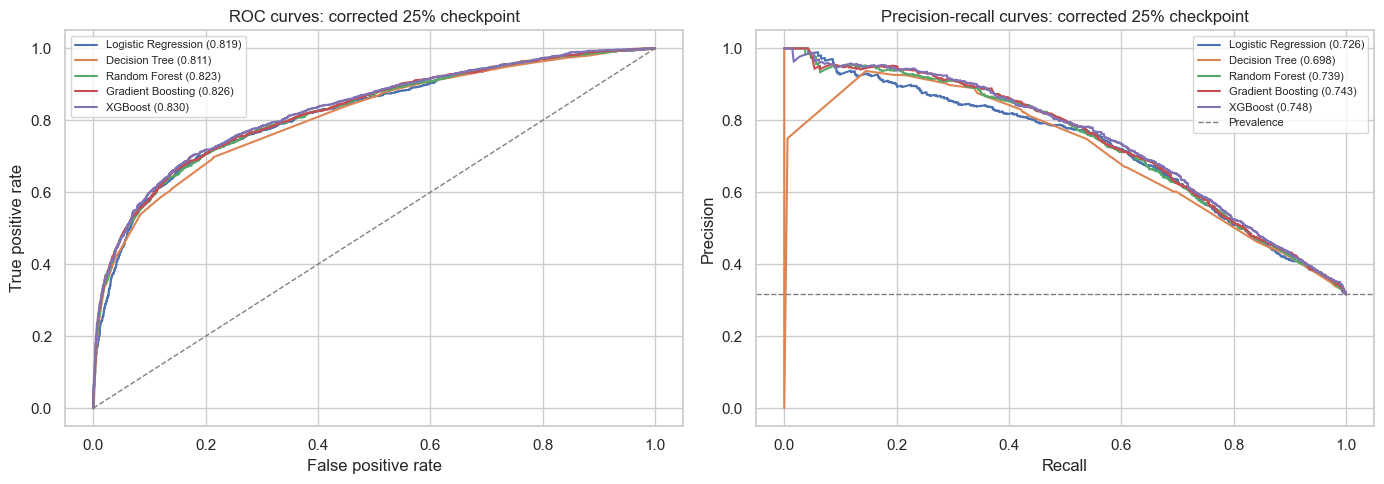

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_eval_25 = corrected_25pct.iloc[eval_idx]["target_withdrawn"]
for model_name, probability in pct25_probabilities.items():
    fpr, tpr, _ = roc_curve(y_eval_25, probability)
    axes[0].plot(fpr, tpr, label=f"{model_name} ({roc_auc_score(y_eval_25, probability):.3f})")
    precision, recall, _ = precision_recall_curve(y_eval_25, probability)
    axes[1].plot(recall, precision, label=f"{model_name} ({average_precision_score(y_eval_25, probability):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
axes[0].set(title="ROC curves: corrected 25% checkpoint", xlabel="False positive rate", ylabel="True positive rate")
axes[1].axhline(y_eval_25.mean(), linestyle="--", color="grey", linewidth=1, label="Prevalence")
axes[1].set(title="Precision-recall curves: corrected 25% checkpoint", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Compact fairness audit

This is a descriptive audit of the best corrected 25%-checkpoint mentor model at threshold 0.5. It is not a full reproduction of the source paper's AMR bootstrap or threshold-calibration study.

In [12]:
best_25_row = pct25_results.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0]
best_25_model = best_25_row["model"]
best_25_probability = pct25_probabilities[best_25_model]
best_25_prediction = (best_25_probability >= 0.5).astype(int)

fair_eval = corrected_25pct.iloc[eval_idx].reset_index(drop=True).copy()
fair_eval["prediction"] = best_25_prediction
fair_eval["target"] = y_eval_25.reset_index(drop=True)
fair_eval["intersection_group"] = np.select(
    [
        (fair_eval.disability == "Y") & (fair_eval.imd_deprived == 1),
        (fair_eval.disability == "Y") & (fair_eval.imd_deprived == 0),
        (fair_eval.disability == "N") & (fair_eval.imd_deprived == 1),
    ],
    ["Disabled & Deprived", "Disabled only", "Deprived only"],
    default="Neither",
)

def group_metric_rows(frame, attribute, positive_group, reference_group):
    rows = []
    for group_name in [positive_group, reference_group]:
        subset = frame[frame[attribute] == group_name]
        recall = recall_score(subset.target, subset.prediction, zero_division=0)
        rows.append({
            "attribute": attribute,
            "group": group_name,
            "support": len(subset),
            "withdrawn": int(subset.target.sum()),
            "withdrawal_prevalence": subset.target.mean(),
            "recall": recall,
            "fnr": 1 - recall,
            "precision": precision_score(subset.target, subset.prediction, zero_division=0),
        })
    rows[0]["fnr_difference_vs_reference"] = rows[0]["fnr"] - rows[1]["fnr"]
    rows[1]["fnr_difference_vs_reference"] = 0.0
    return rows

fair_eval["disability_group"] = np.where(fair_eval.disability == "Y", "Disabled", "Not disabled")
fair_eval["deprivation_group"] = np.where(fair_eval.imd_deprived == 1, "Bottom 30% IMD", "Other / missing")

fairness_rows = []
fairness_rows += group_metric_rows(fair_eval, "disability_group", "Disabled", "Not disabled")
fairness_rows += group_metric_rows(fair_eval, "deprivation_group", "Bottom 30% IMD", "Other / missing")
fairness_rows += group_metric_rows(fair_eval, "intersection_group", "Disabled & Deprived", "Neither")
fairness_results = pd.DataFrame(fairness_rows)

print("Best corrected 25% model:", best_25_model)
display(fairness_results.style.format({
    "withdrawal_prevalence": "{:.3f}", "recall": "{:.3f}", "fnr": "{:.3f}",
    "precision": "{:.3f}", "fnr_difference_vs_reference": "{:+.3f}",
}))

Best corrected 25% model: XGBoost


,attribute,group,support,withdrawn,withdrawal_prevalence,recall,fnr,precision,fnr_difference_vs_reference
0,disability_group,Disabled,471,184,0.391,0.527,0.473,0.815,+0.019
1,disability_group,Not disabled,4393,1356,0.309,0.546,0.454,0.776,+0.000
2,deprivation_group,Bottom 30% IMD,1040,385,0.370,0.577,0.423,0.793,-0.044
3,deprivation_group,Other / missing,3824,1155,0.302,0.532,0.468,0.777,+0.000
4,intersection_group,Disabled & Deprived,109,46,0.422,0.500,0.500,0.852,+0.032
5,intersection_group,Neither,3462,1017,0.294,0.532,0.468,0.773,+0.000


## How to read the results

- The near-perfect run shows what happens when the model is indirectly given the answer. It is not a usable early-warning result.
- The clean day-28 run checks whether we can reproduce the repository's honest score.
- The corrected day-28 run removes repeated-student and mixed-enrolment problems.
- Only the corrected 25% run can be directly compared with our current baseline.
- The other two repositories predict different outcomes or use different datasets, so their scores cannot replace our baseline.

In [13]:
best_fair = pct25_results.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0].to_dict()
best_leaky = leaky_results.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0].to_dict()
best_source_clean = source_clean_results.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0].to_dict()
best_day28 = day28_results.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0].to_dict()
delta_pr = best_fair["pr_auc"] - BASELINE["pr_auc"]
delta_roc = best_fair["roc_auc"] - BASELINE["roc_auc"]

if delta_pr > 0 and delta_roc > 0:
    decision = (
        f"The corrected mentor implementation beats the frozen baseline on both primary metrics "
        f"(PR-AUC {delta_pr:+.3f}, ROC-AUC {delta_roc:+.3f})."
    )
else:
    decision = (
        f"The corrected mentor implementation does not beat the frozen baseline on both primary metrics "
        f"(PR-AUC {delta_pr:+.3f}, ROC-AUC {delta_roc:+.3f})."
    )

verdict_table = pd.DataFrame([
    {
        "repository": "valakhorasani/oulad-fairness",
        "exact_target": True,
        "reimplemented": True,
        "best_reported_claim": "ROC-AUC 0.995 with outcome-derived features",
        "primary_comparison": f"{best_fair['model']}: PR-AUC {best_fair['pr_auc']:.3f}, ROC-AUC {best_fair['roc_auc']:.3f}",
        "decision": decision,
    },
    {
        "repository": "pranay-ar/UnfairSlayers_Seldonian_oulad",
        "exact_target": False,
        "reimplemented": False,
        "best_reported_claim": "Log-loss/fairness experiment; no comparable ROC/PR-AUC",
        "primary_comparison": "Fail + Withdrawn versus Pass + Distinction",
        "decision": "Ineligible for direct performance comparison",
    },
    {
        "repository": "KANUBALAD/ML-Fairness-in-School-DropOut-",
        "exact_target": False,
        "reimplemented": False,
        "best_reported_claim": "Accuracy/fairness on non-OULAD datasets",
        "primary_comparison": "Brazil, Africa, and India datasets",
        "decision": "Ineligible for direct performance comparison",
    },
])
display(verdict_table)
print(decision)

dd_fnr_delta = fairness_results.loc[
    (fairness_results["attribute"] == "intersection_group")
    & (fairness_results["group"] == "Disabled & Deprived"),
    "fnr_difference_vs_reference",
].iloc[0]

summary_md = f'''## Executed results and decision

| Setup | Best model by PR-AUC | PR-AUC | ROC-AUC | Directly comparable? |
|---|---|---:|---:|---:|
| Current capstone baseline | HistGradientBoosting | **{BASELINE["pr_auc"]:.3f}** | **{BASELINE["roc_auc"]:.3f}** | Yes |
| Paper-described leaky reconstruction | {best_leaky["model"]} | {best_leaky["pr_auc"]:.3f} | {best_leaky["roc_auc"]:.3f} | No |
| Repository-faithful clean, day 28 | {best_source_clean["model"]} | {best_source_clean["pr_auc"]:.3f} | {best_source_clean["roc_auc"]:.3f} | No |
| Corrected and grouped, day 28 | {best_day28["model"]} | {best_day28["pr_auc"]:.3f} | {best_day28["roc_auc"]:.3f} | No |
| Corrected 25% checkpoint | {best_fair["model"]} | **{best_fair["pr_auc"]:.3f}** | **{best_fair["roc_auc"]:.3f}** | **Yes** |

We reproduced the repository's clean ROC-AUC of about 0.805. The score becomes almost perfect only when the model receives fields that reveal withdrawal. The exact difference between 0.995 and this reconstruction is unimportant: both results show that the model was indirectly given the answer.

Under the only fair comparison, the mentor feature set changes PR-AUC by **{delta_pr:+.3f}** and ROC-AUC by **{delta_roc:+.3f}**. Its Disabled-and-Deprived FNR is **{dd_fnr_delta:+.3f}** relative to the Neither group in the compact descriptive audit.

**Decision:** keep our current HGB baseline. Khorasani predicts the same target, but its valid version performs worse. The Seldonian repository combines `Fail + Withdrawn`, and KANUBALAD uses other datasets, so neither is a direct alternative.
'''
display(Markdown(summary_md))

,repository,exact_target,reimplemented,best_reported_claim,primary_comparison,decision
0,valakhorasani/oulad-fairness,True,True,ROC-AUC 0.995 with outcome-derived features,"XGBoost: PR-AUC 0.748, ROC-AUC 0.830",The corrected mentor implementation does not b...
1,pranay-ar/UnfairSlayers_Seldonian_oulad,False,False,Log-loss/fairness experiment; no comparable RO...,Fail + Withdrawn versus Pass + Distinction,Ineligible for direct performance comparison
2,KANUBALAD/ML-Fairness-in-School-DropOut-,False,False,Accuracy/fairness on non-OULAD datasets,"Brazil, Africa, and India datasets",Ineligible for direct performance comparison


The corrected mentor implementation does not beat the frozen baseline on both primary metrics (PR-AUC -0.077, ROC-AUC -0.054).


## Executed results and decision

| Setup | Best model by PR-AUC | PR-AUC | ROC-AUC | Directly comparable? |
|---|---|---:|---:|---:|
| Current capstone baseline | HistGradientBoosting | **0.825** | **0.884** | Yes |
| Paper-described leaky reconstruction | Gradient Boosting | 1.000 | 1.000 | No |
| Repository-faithful clean, day 28 | XGBoost | 0.702 | 0.806 | No |
| Corrected and grouped, day 28 | XGBoost | 0.702 | 0.785 | No |
| Corrected 25% checkpoint | XGBoost | **0.748** | **0.830** | **Yes** |

We reproduced the repository's clean ROC-AUC of about 0.805. The score becomes almost perfect only when the model receives fields that reveal withdrawal. The exact difference between 0.995 and this reconstruction is unimportant: both results show that the model was indirectly given the answer.

Under the only fair comparison, the mentor feature set changes PR-AUC by **-0.077** and ROC-AUC by **-0.054**. Its Disabled-and-Deprived FNR is **+0.032** relative to the Neither group in the compact descriptive audit.

**Decision:** keep our current HGB baseline. Khorasani predicts the same target, but its valid version performs worse. The Seldonian repository combines `Fail + Withdrawn`, and KANUBALAD uses other datasets, so neither is a direct alternative.


In [14]:
result_record = {
    "target": "Withdrawn vs Pass/Fail/Distinction",
    "frozen_baseline": BASELINE,
    "row_split_overlap_audit": overlap_audit.iloc[0].to_dict(),
    "feature_audit": feature_audit.to_dict(orient="records"),
    "leaky_reconstruction_results": leaky_results.to_dict(orient="records"),
    "source_clean_results": source_clean_results.to_dict(orient="records"),
    "corrected_day28_results": day28_results.to_dict(orient="records"),
    "corrected_25pct_results": pct25_results.to_dict(orient="records"),
    "compact_fairness_audit": fairness_results.to_dict(orient="records"),
    "best_fair_delta_pr_auc": float(delta_pr),
    "best_fair_delta_roc_auc": float(delta_roc),
    "decision": decision,
}
print("MENTOR_IMPLEMENTATIONS_RESULT_JSON=" + json.dumps(result_record, default=float))

MENTOR_IMPLEMENTATIONS_RESULT_JSON={"target": "Withdrawn vs Pass/Fail/Distinction", "frozen_baseline": {"variant": "Current checkpoint1_EDA_v3 HGB", "model": "HistGradientBoosting, withdrawal weight 3.0", "window": "25% course-relative", "split": "student-grouped evaluation", "pr_auc": 0.8248301223758441, "roc_auc": 0.8841793059527716, "balanced_accuracy": 0.8191925703658556, "precision": 0.6929971988795518, "recall": 0.8032467532467532, "f1": 0.7440601503759399, "fp": 548, "fn": 303}, "row_split_overlap_audit": {"rows": 32593.0, "unique_students": 28785.0, "students_with_multiple_enrolments": 3538.0, "train_test_student_overlap": 1121.0, "test_students_seen_in_train_pct": 17.58983210418955, "minimum_25pct_day": 58.0, "maximum_25pct_day": 67.0}, "feature_audit": [{"variant": "Paper-described leaky reconstruction", "target": "Withdrawn vs Others", "window": "day 28 plus outcome-derived evidence", "aggregation_key": "student only for VLE; enrolment for direct leakage", "raw_predictors": 

## Simple conclusion and key differences

### 1. Did any repository solve exactly our problem?

Only Khorasani used the same label: **Withdrawn versus all other final outcomes**. The Seldonian repository combines `Fail + Withdrawn`, while KANUBALAD uses different datasets.

### 2. Why did Khorasani sometimes obtain an almost perfect score?

The almost perfect result uses information such as whether an unregistration was eventually recorded and whether an assessment was ever submitted. These fields can reveal that withdrawal has already happened. The model is therefore being given part of the answer. When those fields are removed, we reproduce the much lower and more realistic ROC-AUC of about **0.806**.

### 3. We also use assessment submissions and scores. Why is our use different?

Assessment data is not automatically leakage. Timing determines whether it is valid.

- **Our model:** uses only assessments already due by the 25% checkpoint and only submissions and scores recorded by that day.
- **Invalid/leaky use:** looks at whether a student ever submitted, uses scores recorded after the checkpoint, or uses the eventual unregistration record.

For example:

- “The student did not submit an assessment that was due by day 60” is valid information at day 60.
- “The student never submitted that assessment during the whole course” uses future information.
- “The student has an unregistration date” effectively reveals the withdrawal outcome.

### 4. Other important differences

- Khorasani's clean model observes only through **day 28**, approximately 10–12% of a course. Our checkpoint is around **day 58–67**.
- Their original split places **1,121 students** in both training and test data. Our grouped split prevents this.
- Their original VLE aggregation can mix a student's activity from different enrolments. Our corrected comparison keeps each student–module–presentation separate.

### 5. Final result

Under the fair 25% comparison, the best mentor model achieved PR-AUC **0.748** and ROC-AUC **0.830**. Our current HGB baseline remains better at PR-AUC **0.825** and ROC-AUC **0.884**.

**Decision: retain the current HGB baseline.**

